#Importamos paquetes

---



In [1]:
from ast import increment_lineno
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

### Importamos el conjunto de datos

In [33]:
df = pd.read_csv("Data_PI_regresion.csv")
df.head()

,Temperatura,Horas_Operacion,Carga,Humedad,Consumo_Energia
0,29.8,7.4,76.4,87.0,28.97
1,22.9,4.3,88.8,74.9,21.85
2,21.9,10.4,87.7,65.7,37.43
3,27.4,7.8,55.7,79.0,26.32
4,30.2,6.9,42.3,62.9,26.08


## Consultar información del archivo

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Temperatura      5000 non-null   float64
 1   Horas_Operacion  5000 non-null   float64
 2   Carga            5000 non-null   float64
 3   Humedad          5000 non-null   float64
 4   Consumo_Energia  5000 non-null   float64
dtypes: float64(5)
memory usage: 195.4 KB


In [5]:
df.describe().round(1)

,Temperatura,Horas_Operacion,Carga,Humedad,Consumo_Energia
count,5000.0,5000.0,5000.0,5000.0,5000.0
mean,26.5,7.0,65.0,65.1,26.0
std,4.9,2.9,20.3,14.3,5.6
min,18.0,2.0,30.0,40.0,9.1
25%,22.1,4.4,47.3,52.7,21.8
50%,26.5,7.0,65.7,65.0,26.1
75%,30.7,9.4,82.5,77.5,30.3
max,35.0,12.0,100.0,90.0,42.6


In [6]:
df.columns

Index(['Temperatura', 'Horas_Operacion', 'Carga', 'Humedad',
       'Consumo_Energia'],
      dtype='object')

### Distribución del consumo de energía

'\nHistograma: ¿Cómo se distribuyen los datos por intervalos?\n'

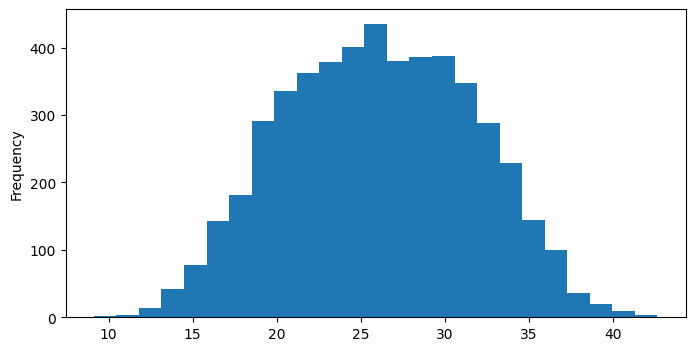

In [8]:
df['Consumo_Energia'].plot.hist(bins=25, figsize=(8,4))
# histograma en 25 intervalos

'''
Histograma: ¿Cómo se distribuyen los datos por intervalos?
'''
# figsize(ancho,alto): tamaño de la figura

'\nDensidad: ¿Dónde están concentrados los datos?\n'

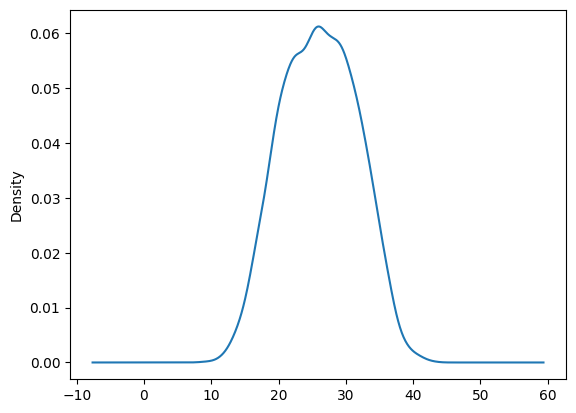

In [9]:
df['Consumo_Energia'].plot.density()
'''
Densidad: ¿Dónde están concentrados los datos?
'''

### Matriz de correlación y heatmap

In [11]:
numeric_df = df.select_dtypes(include=[np.number])
# Selecciona solo las columnas con valores numéricos

numeric_df.corr().round(4)
#Cálculo de la correlación

,Temperatura,Horas_Operacion,Carga,Humedad,Consumo_Energia
Temperatura,1.0000,-0.0260,0.0102,0.0166,0.0978
Horas_Operacion,-0.0260,1.0000,-0.0099,0.0060,0.8434
Carga,0.0102,-0.0099,1.0000,0.0060,0.3366
Humedad,0.0166,0.0060,0.0060,1.0000,0.0627
Consumo_Energia,0.0978,0.8434,0.3366,0.0627,1.0000


<Axes: >

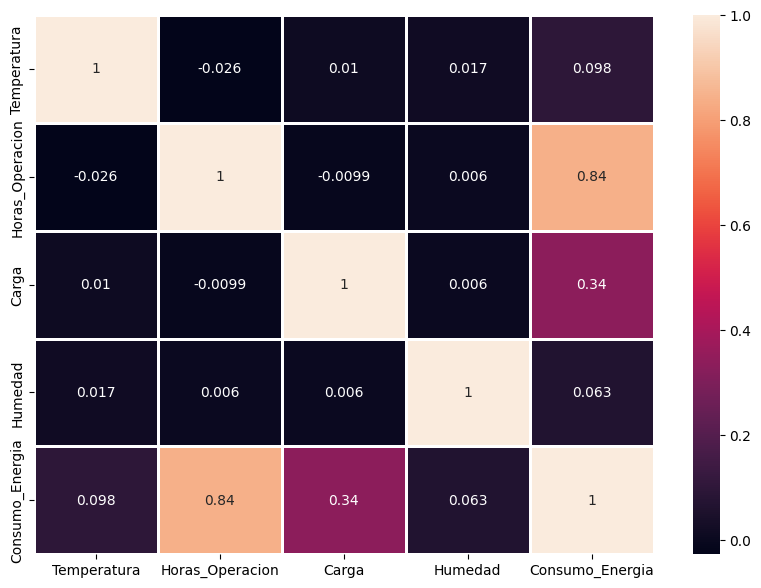

In [12]:
plt.figure(figsize=(10,7))
sns.heatmap(numeric_df.corr(),annot=True,linewidths=2)
# Mapa de calor de correlaciones

### Conjuntos de características y variables

In [14]:
l_column = list(df.columns)
len_feature = len(l_column)
l_column

['Temperatura', 'Horas_Operacion', 'Carga', 'Humedad', 'Consumo_Energia']

### Regresión lineal

In [16]:
x = df[l_column[0:len_feature-1]]
y = df[l_column[len_feature-1]]
x.head()

,Temperatura,Horas_Operacion,Carga,Humedad
0,29.8,7.4,76.4,87.0
1,22.9,4.3,88.8,74.9
2,21.9,10.4,87.7,65.7
3,27.4,7.8,55.7,79.0
4,30.2,6.9,42.3,62.9


### Dividimos entrenamiento-prueba

In [17]:
from sklearn.model_selection import train_test_split
#divide datos en: entrenamiento y prueba

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    x,y, test_size=0.3, random_state=123
)
#70%: entrenamiento
#30%: prueba
# random_state= 123 >> Haz la dicisión aleatoria, pero repoducible

### Ajuste y entrenamiento del modelo

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn import metrics
# machine learning
# modelo: regresión lineal
# métricas: ¿Qué tan buenas son las predicciones?

In [21]:
lm = LinearRegression() # Creando un objeto de Regresión Lineal 'lm'

In [22]:
lm.fit(X_train,y_train) # Ajustar y entrenar

LinearRegression()

In [23]:
# Verificamos la intercepsión
print("Los coeficientes de intersección del modelo lineal: ", lm.intercept_)

Los coeficientes de intersección del modelo lineal:  2.741067446117448


In [24]:
# Verificamos el modelo lineal
print("Los coeficientes del modelo lineal: ", lm.coef_)

Los coeficientes del modelo lineal:  [0.13713677 1.66877804 0.09634816 0.02679108]


In [25]:
cdf = pd.DataFrame(data=lm.coef_,index=X_train.columns, columns=["Coefficients"])
cdf

,Coefficients
Temperatura,0.137137
Horas_Operacion,1.668778
Carga,0.096348
Humedad,0.026791


### Cálculo de errores y estadística t para los coeficientes

In [26]:
n = X_train.shape[0]  # cantidad de datos de entrenamiento
k = X_train.shape[1]  # cantidad de variables: 4
df = n - k  # grados de libertad
train_pred = lm.predict(X_train)  # obtener predicciones

# calculamos el error: R^2
train_error = np.square(train_pred - y_train)  # comparamos (prediccion - valor real)**2
sum_error = np.sum(train_error)  # suma de errores
# ¿qué tanto se equivocó el modelo?

se = [0, 0, 0, 0]
for i in range(k):
    r = (sum_error / df)
    # ¿cuánto varía el valor respecto a su promedio?
    # selecciona variable: 'Temperatura' calcula la Temperatura promedio
    r = r / np.sum(np.square(X_train[list(X_train.columns)[i]] - X_train[list(X_train.columns)[i]].mean()))
    se[i] = np.sqrt(r)  # cálculo del error estándar

cdf['Standard Error'] = se
cdf['t-statistic'] = cdf['Coefficients'] / cdf['Standard Error']
# ¿El coeficiente es grande en comparación con la incertidumbre que tiene?
# ¿está alejado de cero respecto a su error estándar?
cdf

,Coefficients,Standard Error,t-statistic
Temperatura,0.137137,0.007557,18.147233
Horas_Operacion,1.668778,0.013138,127.020720
Carga,0.096348,0.001859,51.826973
Humedad,0.026791,0.002611,10.260097


Text(0.5, 1.0, 'Humedad vs. Consumo_Energia')

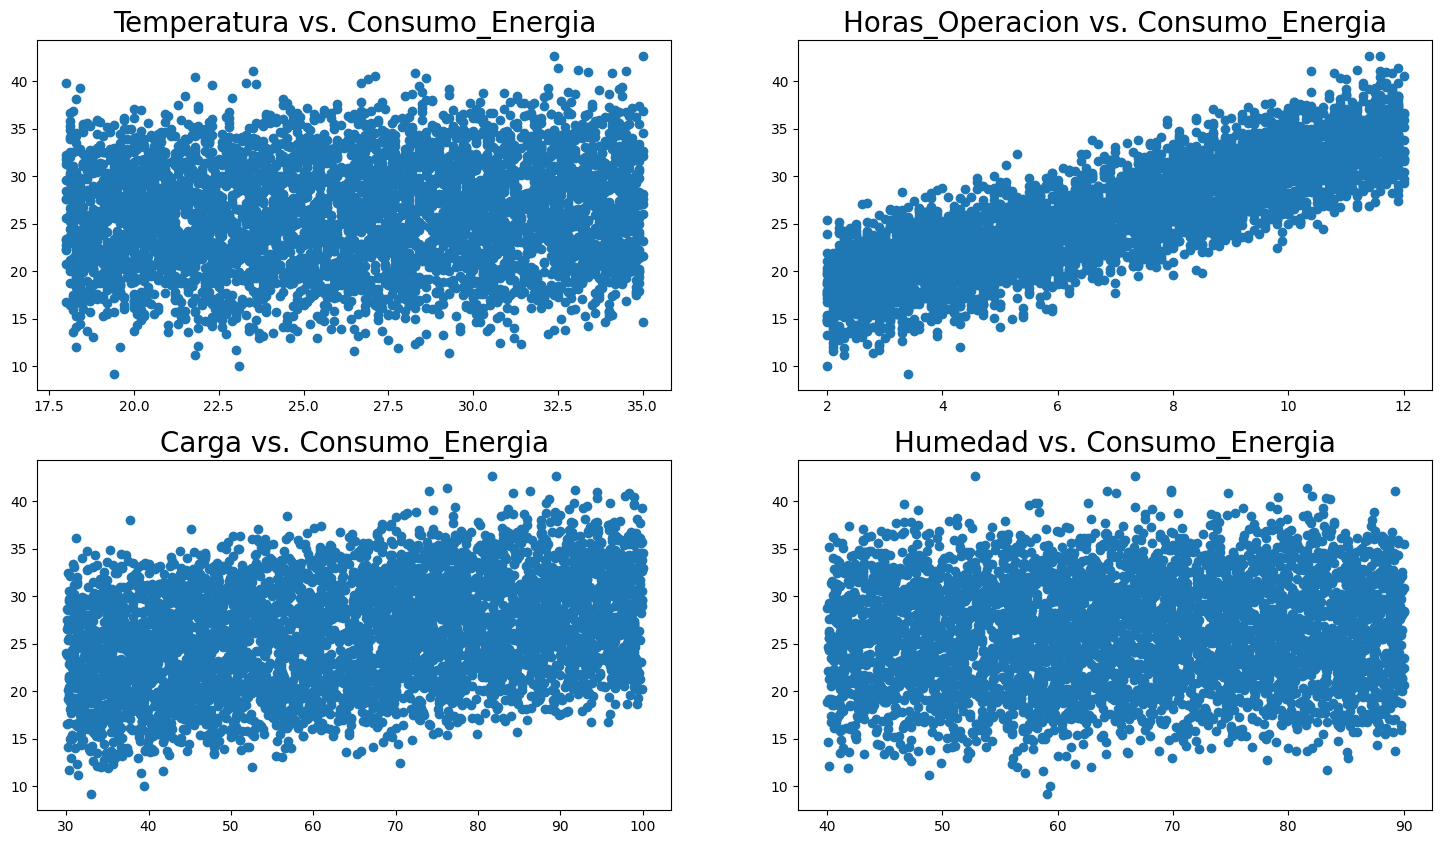

In [34]:
l = list(cdf.index)

from matplotlib import gridspec
fig = plt.figure(figsize=(18, 10))
gs = gridspec.GridSpec(2, 2)

ax0 = plt.subplot(gs[0])
ax0.scatter(df[l[0]], df['Consumo_Energia'])
ax0.set_title(l[0] + " vs. Consumo_Energia", fontdict={'fontsize': 20})

ax1 = plt.subplot(gs[1])
ax1.scatter(df[l[1]], df['Consumo_Energia'])
ax1.set_title(l[1] + " vs. Consumo_Energia", fontdict={'fontsize': 20})

ax2 = plt.subplot(gs[2])
ax2.scatter(df[l[2]], df['Consumo_Energia'])
ax2.set_title(l[2] + " vs. Consumo_Energia", fontdict={'fontsize': 20})

ax3 = plt.subplot(gs[3])
ax3.scatter(df[l[3]], df['Consumo_Energia'])
ax3.set_title(l[3] + " vs. Consumo_Energia", fontdict={'fontsize': 20})

### Matrices de evalución de predicción, estimación de error y regresión

In [35]:
predictions = lm.predict(X_test)
print("Tipo del objeto predicho: ", type(predictions))
print("Tamaño del objeto predicho: ", predictions.shape)

Tipo del objeto predicho:  <class 'numpy.ndarray'>
Tamaño del objeto predicho:  (1500,)


Text(0, 0.5, 'Consumo de energía predicho')

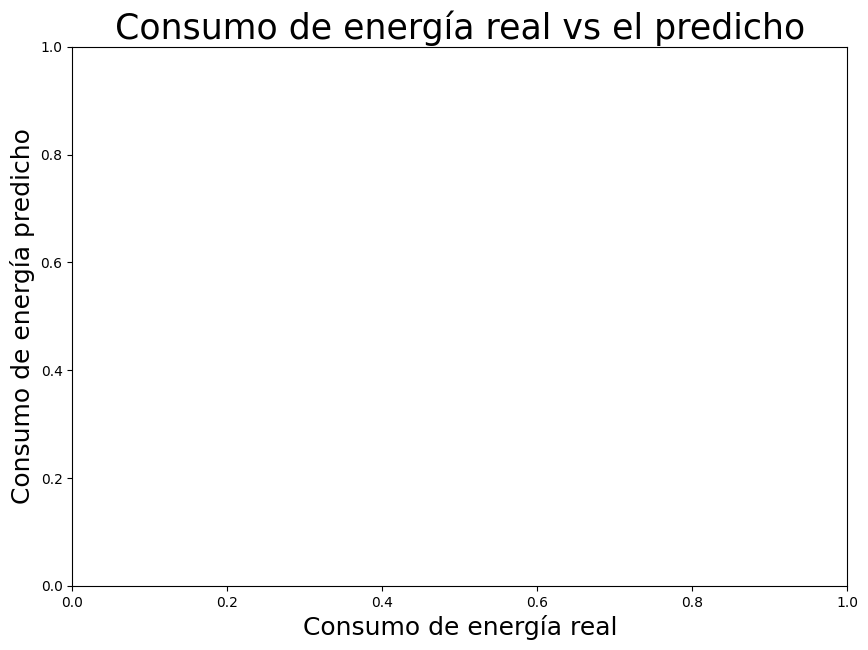

In [36]:
plt.figure(figsize=(10,7))
plt.title("Consumo de energía real vs el predicho",fontsize=25)
plt.xlabel("Consumo de energía real", fontsize=18)
plt.ylabel("Consumo de energía predicho", fontsize = 18)


/tmp/ipykernel_1122/2536154357.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot([y_test - predictions])  # histplot


<Axes: title={'center': 'Histograma de residuos para verificar la normalidad '}, xlabel='Residuos', ylabel='Densidad del kernel'>

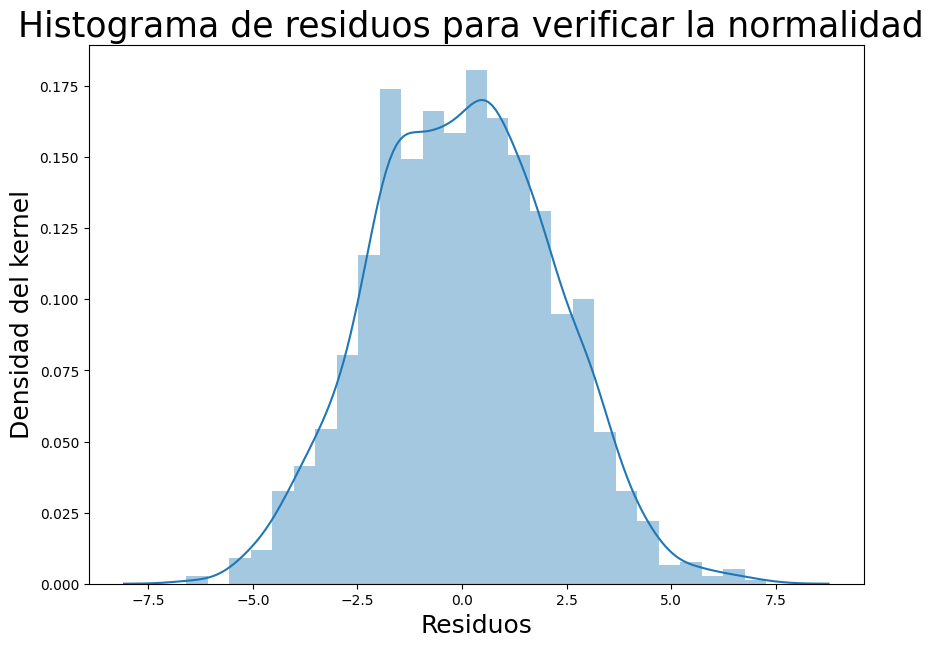

In [37]:
plt.figure(figsize=(10, 7))
plt.title("Histograma de residuos para verificar la normalidad ", fontsize=25)
plt.xlabel("Residuos", fontsize=18)
plt.ylabel("Densidad del kernel", fontsize=18)
sns.distplot([y_test - predictions])  # histplot
# A futuro se eliminará distplot

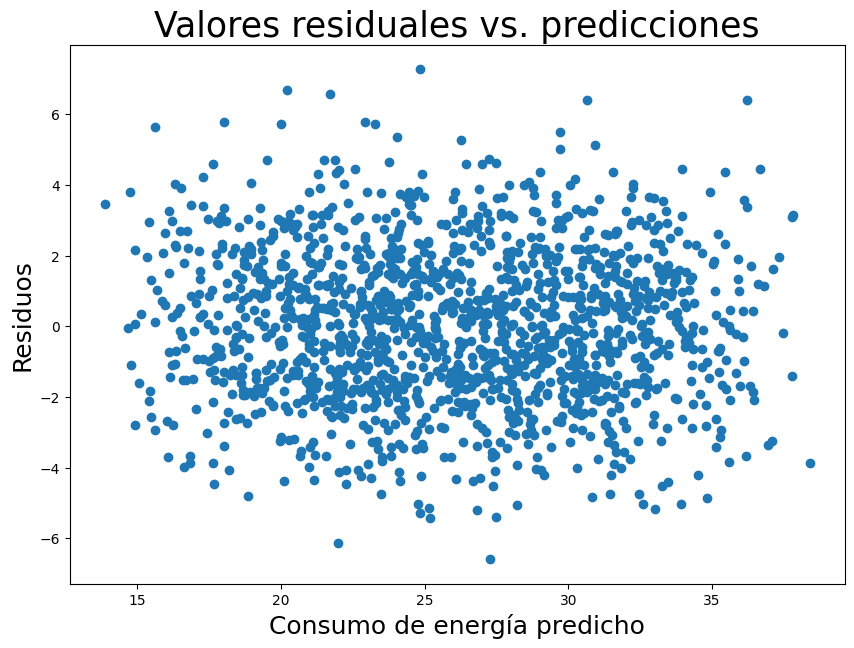

In [39]:
# Diagrama de dispersión (Homocedasticidad)

# El error no aumenta respecto de las predicciones

plt.figure(figsize=(10, 7))

plt.title("Valores residuales vs. predicciones", fontsize=25)
plt.xlabel("Consumo de energía predicho", fontsize=18)
plt.ylabel("Residuos", fontsize=18)

plt.scatter(x=predictions, y=y_test - predictions)

plt.show()

### Random Forest

In [40]:
import matplotlib.pyplot as plt
%matplotlib inline

import pandas as pd
import numpy as np

# Importar el método make_regression para generar muestras de datos artificiales
from sklearn.datasets import make_regression

In [41]:
n_samples = 100  # Número de muestras
n_features = 6  # Número de características

n_informative = 3  # Número de características informativas,
                   # es decir, características reales que influyen en la salida

In [42]:
x, y, coef = make_regression(
    n_samples=n_samples,
    n_features=n_features,
    n_informative=n_informative,
    random_state=20,  # semilla aleatoria (reproducibilidad)
    shuffle=False,    # que no se mezclen las características
    noise=20,         # ruido aleatorio
    coef=True
)

print(coef)  # devuelve los coeficientes

[78.58638696 97.72361019 52.30606265  0.          0.          0.        ]


### Data Frame

In [44]:
df1 = pd.DataFrame(data=x, columns=['X' + str(i) for i in range(1, n_features + 1)])
df2 = pd.DataFrame(data=y, columns=['y'])
df = pd.concat([df1, df2], axis=1)
df.head(10)

,X1,X2,X3,X4,X5,X6,y
0,0.883893,0.195865,0.357537,-2.343262,-1.084833,0.559696,109.512132
1,0.939469,-0.978481,0.503097,0.406414,0.323461,-0.493411,52.542242
2,-0.792017,-0.842368,-1.279503,0.245715,-0.044195,1.567633,-247.679018
3,1.051109,0.406368,-0.168646,-3.189703,1.120132,1.332778,98.678111
4,-0.243339,-0.130031,-0.109017,1.556186,0.128778,-2.066949,-55.286890
5,-0.885493,-1.104579,0.932866,2.059838,-0.934938,-1.612990,-94.821349
6,0.527070,-1.551101,0.329613,-1.136527,-0.338491,0.320971,-75.940071
7,-0.602308,1.544728,0.647034,0.593217,0.438024,1.357789,139.247064
8,1.204511,1.351796,0.493437,-2.704365,-0.555186,0.001509,246.470338
9,0.857094,1.481144,-0.219661,1.503398,-1.482385,-0.856164,204.709196


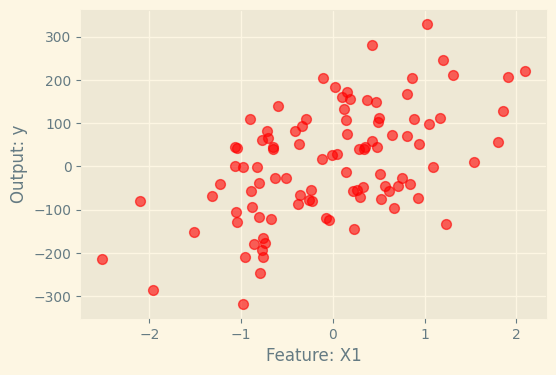

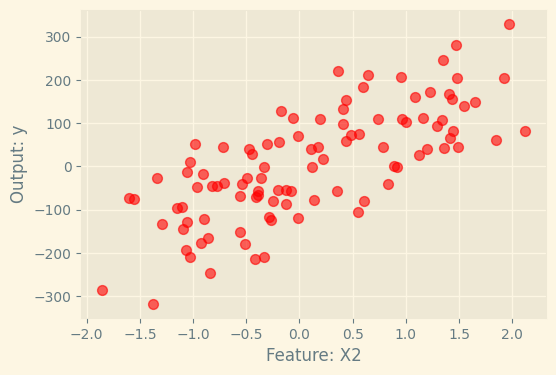

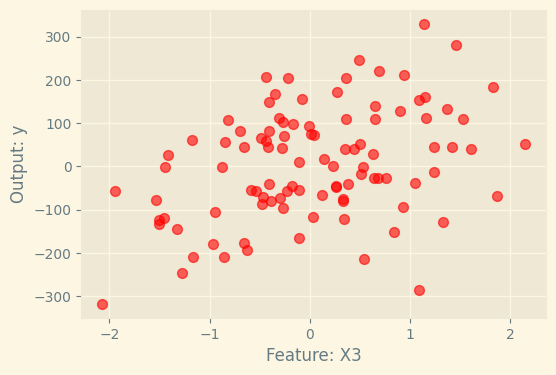

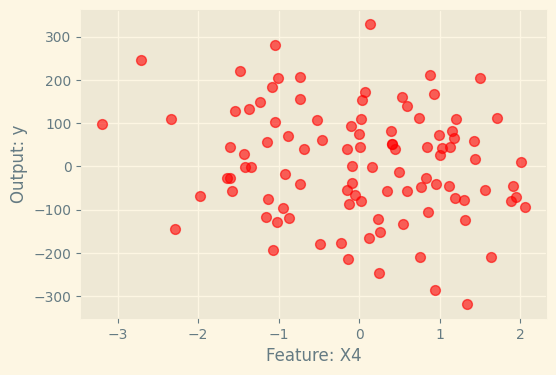

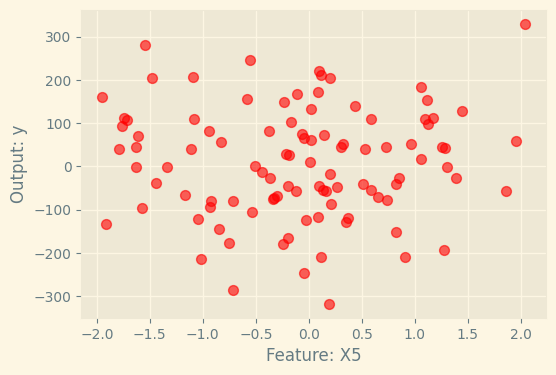

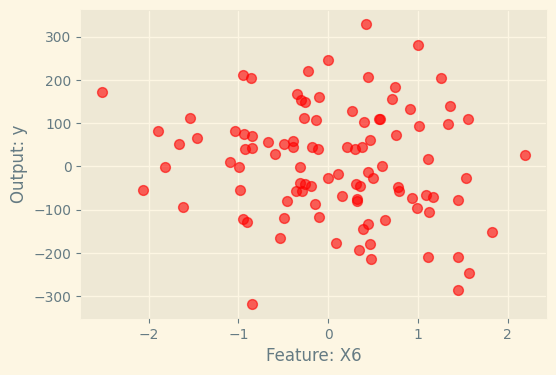

In [45]:
with plt.style.context('Solarize_Light2'):
    for i, col in enumerate(df.columns[:-1]):
        plt.figure(figsize=(6, 4))
        plt.grid(True)
        plt.xlabel('Feature: ' + col, fontsize=12)
        plt.ylabel('Output: y', fontsize=12)
        plt.scatter(df[col], df['y'], c='red', s=50, alpha=0.6)

In [46]:
from sklearn import tree
from sklearn.model_selection import train_test_split

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=123
)

In [50]:
# Creación del modelo
tree_model = tree.DecisionTreeRegressor(max_depth=5, random_state=10)
# niveles de decisión
tree_model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5, random_state=10)

Mean square error (MSE): 7931.574768958281


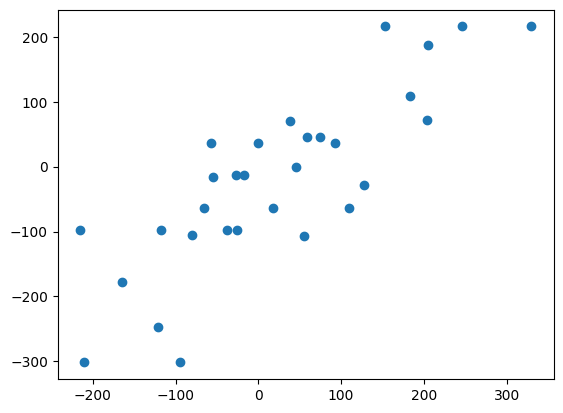

In [53]:
from sklearn import metrics
# Hacemos predicciones
test_pred = tree_model.predict(X_test)

plt.scatter(x=y_test, y=test_pred)  # real vs predicho

print("Mean square error (MSE):", metrics.mean_squared_error(y_test, test_pred))

# Error cuadrático medio

Importancia relativa de las características:  [0.26900246 0.53730467 0.11075698 0.03758107 0.01219288 0.03316193]


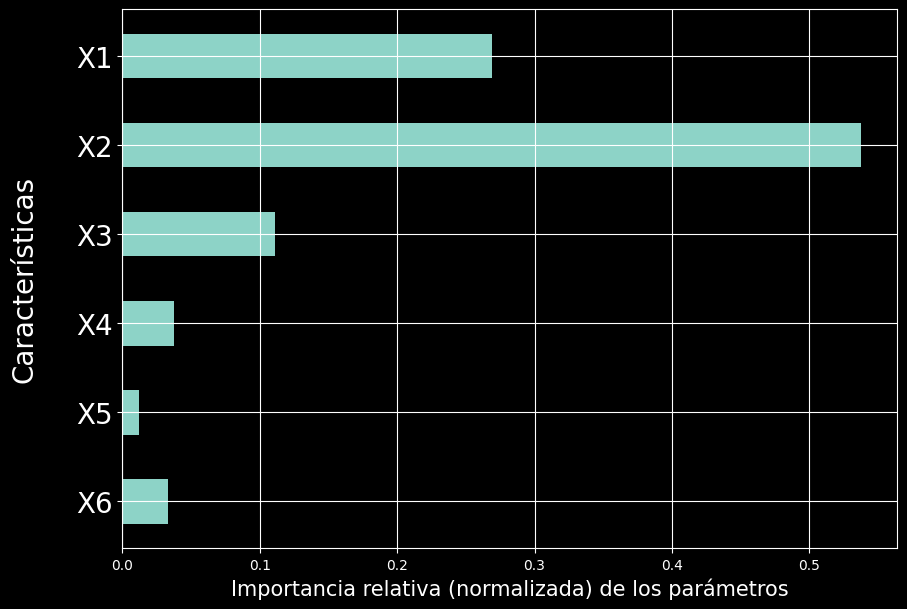

In [54]:
print("Importancia relativa de las características: ", tree_model.feature_importances_)
with plt.style.context('dark_background'):
    plt.figure(figsize=(10, 7))
    plt.grid(True)
    plt.yticks(range(n_features + 1, 1, -1), df.columns[:-1], fontsize=20)
    plt.xlabel("Importancia relativa (normalizada) de los parámetros", fontsize=15)
    plt.ylabel("Características\n", fontsize=20)
    plt.barh(range(n_features + 1, 1, -1), width=tree_model.feature_importances_, height=0.5)

### Minimos cuadrados

In [55]:
import statsmodels.api as sm

In [56]:
Xs = sm.add_constant(x)
stat_model = sm.OLS(y, Xs)
stat_result = stat_model.fit()
print(stat_result.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.976
Model:                            OLS   Adj. R-squared:                  0.974
Method:                 Least Squares   F-statistic:                     628.6
Date:                Tue, 15 Sep 2026   Prob (F-statistic):           5.97e-73
Time:                        21:23:44   Log-Likelihood:                -440.25
No. Observations:                 100   AIC:                             894.5
Df Residuals:                      93   BIC:                             912.7
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.8565      2.087     -1.848      0.0